# 03 — Evaluation
**Skin Lesion Classification in Thermal Images**

Este notebook **carrega e analisa** os resultados de um treino já executado por `scripts/train_cv.py` — ele não treina nada. Rode o script primeiro (`python scripts/train_cv.py` para o run completo, com ~5h em Apple Silicon; `--quick-test` para validar o pipeline rapidamente no subconjunto pequeno) e então use este notebook para gerar matrizes de confusão, curvas ROC, curvas de treino do fold 0 e as tabelas comparativas finais (accuracy, F1-score, AUC-ROC) entre ThermalCNN, ResNet18, SVM e Random Forest.

## 1. Configuração do run e visão geral do dataset

In [12]:
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.dataset import CLASSES, _build_loaders_from_splits, _collect_samples, _patient_kfold_split
from src.evaluate import plot_confusion_matrix, plot_roc_curve, plot_training_curves

RUNS_DIR = Path("../results/runs")

# Nome da pasta em results/runs/ a analisar. Deixe None para pegar a mais
# recente automaticamente, ou defina explicitamente (ex.: "20260707_153200")
# para fixar qual run está sendo citado na análise — importante para
# reprodutibilidade ao escrever o TCC.
RUN_NAME = None

# Só considera pastas no formato atual (com train_config.json) — results/runs/
# também guarda runs "legacy_*" pré-refactor (split único, sem k-fold), que não
# têm os artefatos que este notebook espera (predictions_*.npz, metrics_cv_folds*.csv
# etc.) e não devem ser escolhidas automaticamente como "a mais recente".
valid_runs = [
    p for p in (RUNS_DIR.iterdir() if RUNS_DIR.is_dir() else [])
    if p.is_dir() and (p / "train_config.json").exists()
]
if not valid_runs:
    raise FileNotFoundError(
        f"Nenhuma run no formato atual encontrada em {RUNS_DIR.resolve()}. Rode o treino primeiro, por exemplo:\n"
        f'  python scripts/train_cv.py --quick-test --notes "..."   # validação rápida\n'
        f'  python scripts/train_cv.py --notes "..."                # run completo (~5h)'
    )

if RUN_NAME is None:
    RUN_NAME = max(valid_runs, key=lambda p: p.stat().st_mtime).name

RESULTS_DIR = RUNS_DIR / RUN_NAME
print(f"Analisando run: {RUN_NAME}\n")
print((RESULTS_DIR / "RUN.md").read_text())

with open(RESULTS_DIR / "train_config.json") as f:
    train_config = json.load(f)

Analisando run: 20260714_184810

# Run: 20260714_184810

- **Timestamp**: 2026-07-14T18:48:10
- **Git commit**: `0851e15` (mudanças não commitadas: sim)

## O que mudou nesta run

Run D: single-frame + biópsia, frame_stride=10 — isola o efeito do input temporal vs run 143040 (redes têm código idêntico). Primeiro run do pipeline novo (SVM/RF por sequência + predictions_seq/AUC pooled).

## Configuração

Ver `train_config.json` nesta mesma pasta para os hiperparâmetros exatos.

## Resultado

- **Status**: concluído com sucesso
- **Duração**: 1:16:03.914186



In [13]:
# Recomputa (não retreina) a composição dos folds a partir da config salva pelo
# script de treino — percorrer o filesystem e refazer o split por paciente é
# barato (segundos), ao contrário do treino em si.
DATA_ROOT = Path(train_config["data_root"])
FRAME_STRIDE = train_config["frame_stride"]
K_FOLDS = train_config["k_folds"]

samples = _collect_samples(DATA_ROOT, frame_stride=FRAME_STRIDE)
folds = _patient_kfold_split(samples, k=K_FOLDS, seed=train_config["seed"])

print(f"Total de amostras (após stride={FRAME_STRIDE}): {len(samples):,}")
print(f"\n{'Fold':<6} {'Train':>8} {'Val':>8} {'Test':>8} {'TrainP':>8} {'ValP':>6} {'TestP':>6}")
print("-" * 54)
for i, f in enumerate(folds):
    n_train_p = len(set(s["patient_id"] for s in f["train"]))
    n_val_p   = len(set(s["patient_id"] for s in f["val"]))
    n_test_p  = len(set(s["patient_id"] for s in f["test"]))
    print(f"{i:<6} {len(f['train']):>8,} {len(f['val']):>8,} {len(f['test']):>8,} "
          f"{n_train_p:>8} {n_val_p:>6} {n_test_p:>6}")

Total de amostras (após stride=10): 10,931

Fold      Train      Val     Test   TrainP   ValP  TestP
------------------------------------------------------
0         6,687    2,103    2,141       57     19     19
1         6,701    2,127    2,103       57     19     19
2         6,366    2,438    2,127       57     19     19
3         6,371    2,122    2,438       57     19     19
4         6,668    2,141    2,122       57     19     19


In [14]:
# Constrói loaders só do fold 0, para inspeção rápida (shape, normalização, batch de exemplo).
# Os loaders "de verdade" usados no treino são construídos por fold, dentro do loop de CV abaixo.
train_loader, val_loader, test_loader, mean, std = _build_loaders_from_splits(
    folds[0], batch_size=32, num_workers=0,
)
print(f"Média treino (fold 0):  {mean:.4f}")
print(f"Desvio treino (fold 0): {std:.4f}")

# Verifica shape e intervalo de valores de um batch
images, labels = next(iter(train_loader))
print(f"Shape do batch:  {tuple(images.shape)}")   # esperado: (32, 1, 224, 224)
print(f"Dtype:           {images.dtype}")
print(f"Valores min/max: {images.min():.3f} / {images.max():.3f}")
print(f"Labels únicos:   {labels.unique().tolist()}")

Média treino (fold 0):  0.4846
Desvio treino (fold 0): 0.2224
Shape do batch:  (32, 1, 224, 224)
Dtype:           torch.float32
Valores min/max: -2.179 / 1.894
Labels únicos:   [0, 1]


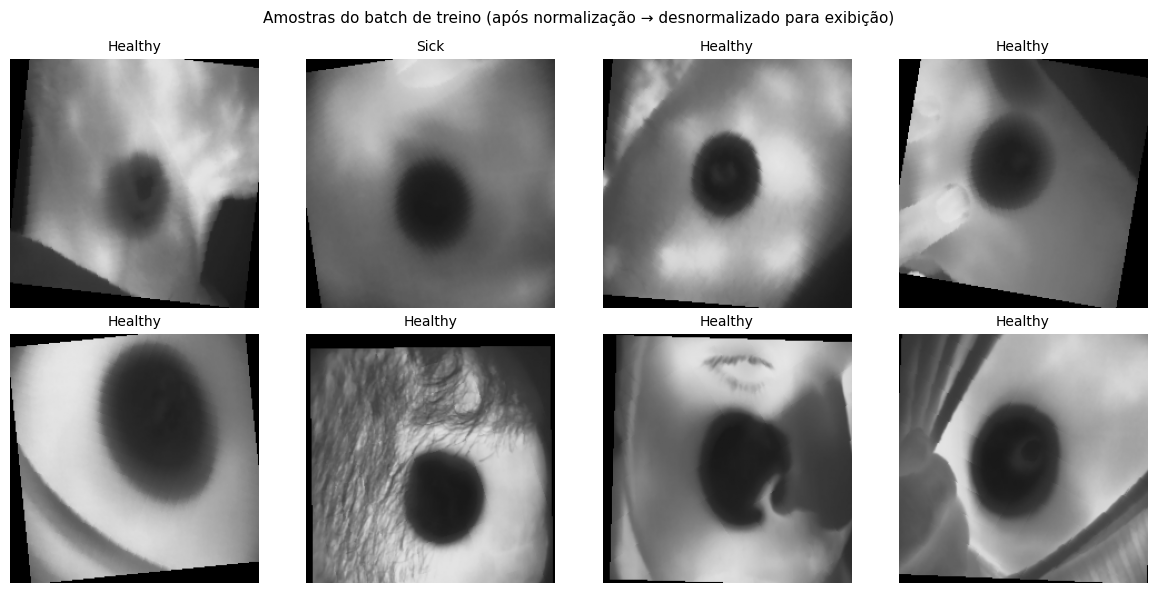

In [15]:
# Visualiza 8 frames do batch com seus labels
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Amostras do batch de treino (após normalização → desnormalizado para exibição)", fontsize=11)

for i, ax in enumerate(axes.flat):
    img = images[i, 0]  # canal único
    img_display = img * std + mean  # desnormaliza para [0, 1]
    ax.imshow(img_display.numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(CLASSES[labels[i].item()], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2. Curvas de treino (fold 0)

Carregadas do histórico salvo por `scripts/train_cv.py` (`history_*_fold0.json`) —
diagnóstico do fold 0 apenas, não a métrica final (essa vem da agregação entre
folds nas seções seguintes).

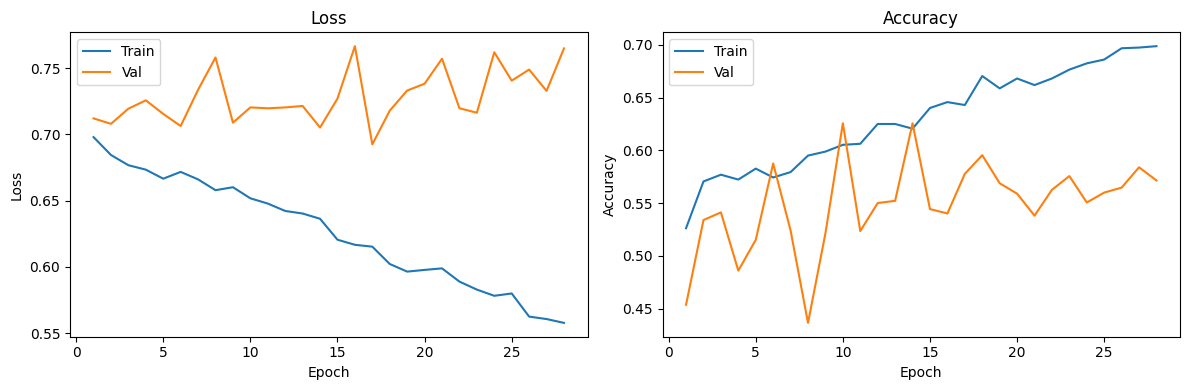

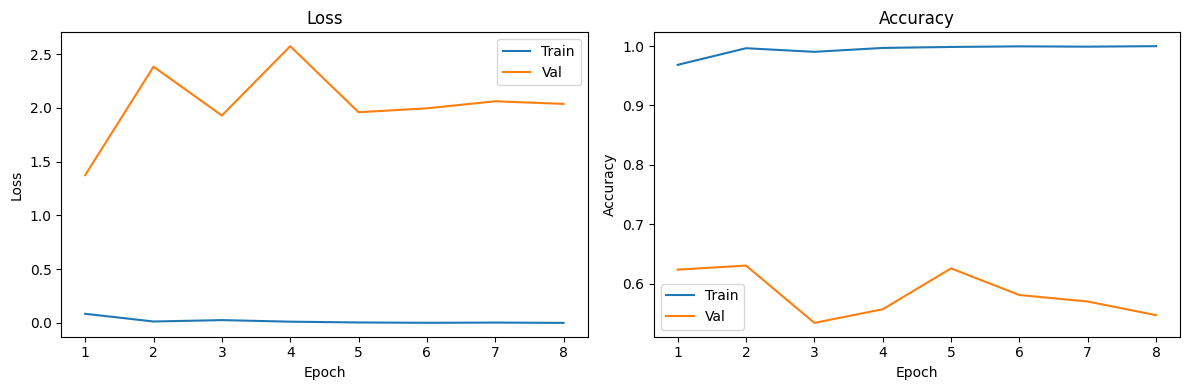

In [16]:
def load_history(model_slug):
    with open(RESULTS_DIR / f"history_{model_slug}_fold0.json") as f:
        return json.load(f)

thermal_cnn_history = load_history("thermal_cnn")
resnet18_history = load_history("resnet18")

plot_training_curves(
    thermal_cnn_history["train_loss"], thermal_cnn_history["val_loss"],
    thermal_cnn_history["train_acc"],  thermal_cnn_history["val_acc"],
    save_path=RESULTS_DIR / "curves_thermal_cnn_fold0.png",
)
plot_training_curves(
    resnet18_history["train_loss"], resnet18_history["val_loss"],
    resnet18_history["train_acc"],  resnet18_history["val_acc"],
    save_path=RESULTS_DIR / "curves_resnet18_fold0.png",
)

## 3. Resultados agregados (predições combinadas de todos os folds)

Matrizes de confusão e curvas ROC construídas a partir das predições de **todos** os
folds de teste combinados (cada paciente contribui exatamente uma vez, no fold em que
foi usado como teste), carregadas de `results/predictions_*.npz` — dão uma visão geral
do comportamento do modelo no dataset completo, complementar à média±desvio por fold
da Seção 4.

In [17]:
MODEL_NAMES = ["ThermalCNN", "ResNet18", "SVM", "Random Forest"]
FILE_SLUG = {"ThermalCNN": "thermal_cnn", "ResNet18": "resnet18", "SVM": "svm", "Random Forest": "rf"}

# Predições consolidadas de todos os folds (probabilidades empilhadas por linha),
# salvas por scripts/train_cv.py — nada é recalculado aqui.
pooled = {}
for name in MODEL_NAMES:
    data = np.load(RESULTS_DIR / f"predictions_{FILE_SLUG[name]}.npz")
    pooled[name] = (data["y_true"], data["y_pred"], data["y_prob"])
    print(f"{name:<15} y_true={data['y_true'].shape}  y_prob={data['y_prob'].shape}")

ThermalCNN      y_true=(10097,)  y_prob=(10097, 2)
ResNet18        y_true=(10097,)  y_prob=(10097, 2)
SVM             y_true=(168,)  y_prob=(168, 2)
Random Forest   y_true=(168,)  y_prob=(168, 2)


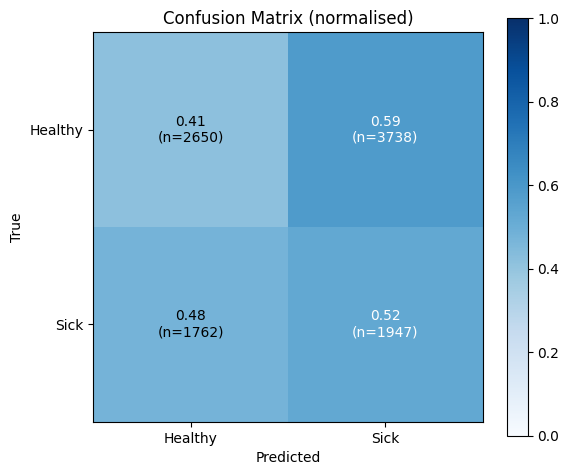

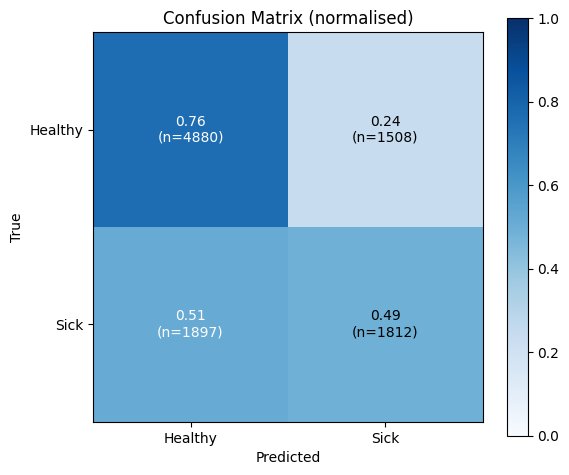

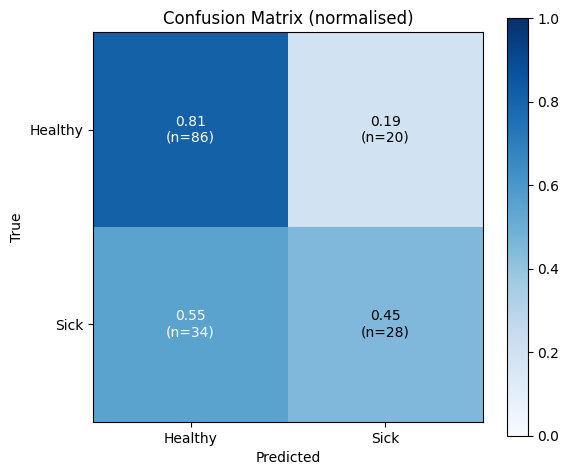

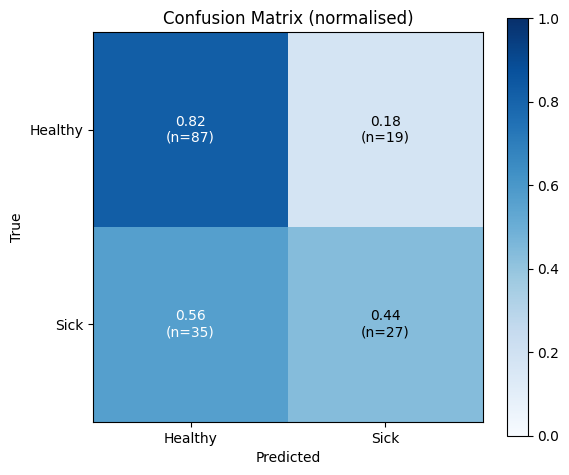

In [18]:
# Matrizes de confusão (predições agregadas de todos os folds)
FILE_SLUG = {"ThermalCNN": "thermal_cnn", "ResNet18": "resnet18", "SVM": "svm", "Random Forest": "rf"}

for name in MODEL_NAMES:
    y_true, y_pred, _ = pooled[name]
    plot_confusion_matrix(y_true, y_pred, CLASSES, save_path=RESULTS_DIR / f"cm_{FILE_SLUG[name]}.png")

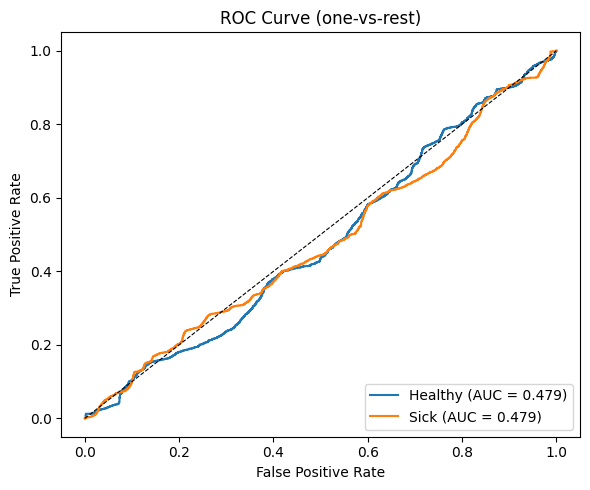

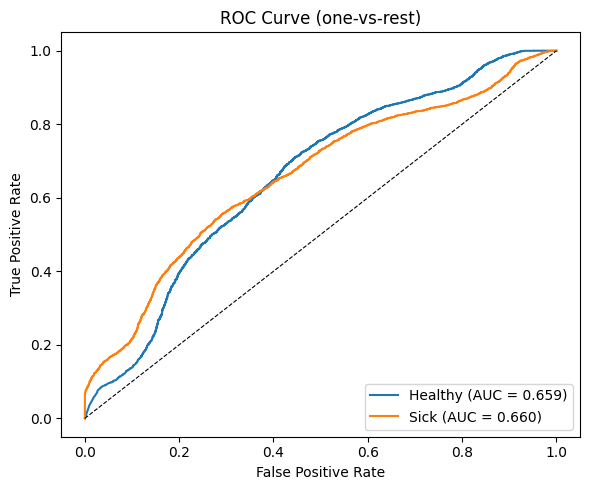

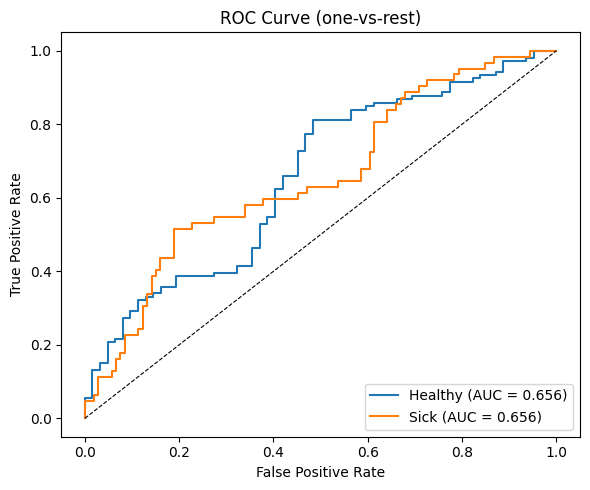

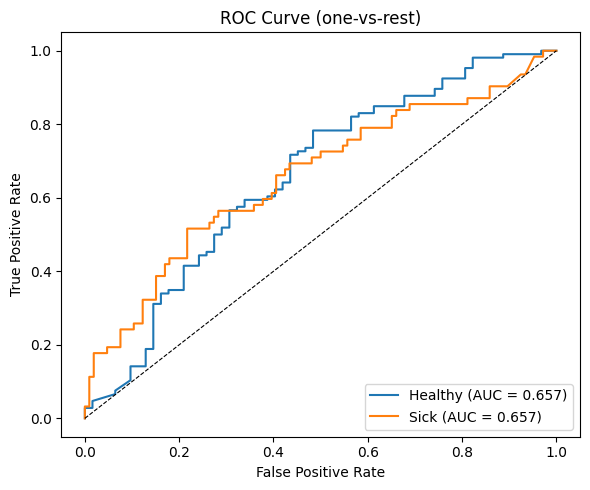

In [19]:
# Curvas ROC (predições agregadas de todos os folds)
for name in MODEL_NAMES:
    y_true, _, y_prob = pooled[name]
    plot_roc_curve(y_true, y_prob, CLASSES, save_path=RESULTS_DIR / f"roc_{FILE_SLUG[name]}.png")

In [20]:
# Métricas por fold (nível frame e nível paciente/sequência), geradas por
# scripts/train_cv.py — carregadas, não recalculadas.
folds_df = pd.read_csv(RESULTS_DIR / "metrics_cv_folds.csv")
folds_seq_df = pd.read_csv(RESULTS_DIR / "metrics_cv_folds_patient.csv")
folds_df

,fold,model,accuracy,precision,recall,specificity,f1,auc_roc
0,0,ThermalCNN,0.421452,0.468315,0.472739,0.261268,0.415978,0.481203
1,0,ResNet18,0.684385,0.684328,0.695847,0.648587,0.679656,0.743386
2,0,SVM,0.676471,0.670139,0.679487,0.666667,0.669319,0.710623
3,0,Random Forest,0.647059,0.626374,0.626374,0.714286,0.626374,0.648352
4,1,ThermalCNN,0.472888,0.419961,0.423552,0.610561,0.421233,0.430234
5,1,ResNet18,0.660584,0.626964,0.609027,0.804455,0.611293,0.738773
6,1,SVM,0.606061,0.564815,0.540385,0.850000,0.519597,0.792308
7,1,Random Forest,0.666667,0.652500,0.617308,0.850000,0.615873,0.807692
8,2,ThermalCNN,0.385441,0.423012,0.443210,0.182582,0.368796,0.487136
9,2,ResNet18,0.664956,0.666833,0.594127,0.913675,0.579294,0.590451


## 4. Tabela comparativa final (média ± desvio padrão entre os folds)

In [21]:
metric_cols = ["accuracy", "precision", "recall", "specificity", "f1", "auc_roc"]

def summarize(df):
    summary = (
        df.groupby("model")[metric_cols]
        .agg(["mean", "std"])
        .reindex(MODEL_NAMES)
    )
    # Achata o índice de colunas multi-nível em "métrica (mean/std)"
    summary.columns = [f"{metric} ({stat})" for metric, stat in summary.columns]
    return summary.round(4)

summary = summarize(folds_df)
summary_csv = RESULTS_DIR / "metrics.csv"
summary.to_csv(summary_csv)
print(f"Resumo nível frame (média±desvio) salvo em {summary_csv}")
summary

Resumo nível frame (média±desvio) salvo em ../results/runs/20260714_184810/metrics.csv


,accuracy (mean),accuracy (std),precision (mean),precision (std),recall (mean),recall (std),specificity (mean),specificity (std),f1 (mean),f1 (std),auc_roc (mean),auc_roc (std)
model,,,,,,,,,,,,
ThermalCNN,0.4544,0.1177,0.3615,0.1181,0.4679,0.0341,0.4109,0.3969,0.3711,0.0674,0.4857,0.0370
ResNet18,0.6632,0.0338,0.6442,0.0412,0.6276,0.0468,0.7652,0.1087,0.6219,0.0453,0.6806,0.0687
SVM,0.6791,0.0639,0.6706,0.0815,0.6340,0.0574,0.8094,0.1355,0.6270,0.0677,0.6915,0.0920
Random Forest,0.6791,0.0411,0.6681,0.0476,0.6332,0.0282,0.8194,0.1040,0.6297,0.0375,0.6768,0.0961


## 5. Tabela comparativa — nível paciente/sequência (agregado)

Mesmas métricas da Seção 4, mas com as predições agregadas por sequência
(patient_id + classe) antes de calcular a métrica — média das probabilidades
softmax de todos os frames de teste de uma mesma sequência, seguida de argmax.
Frames vizinhos de uma sequência térmica são quase idênticos entre si, então essa
agregação deveria reduzir o ruído de frame individual e a variância entre folds
(comparar o desvio-padrão desta tabela com o da Seção 4).

In [22]:
summary_seq = summarize(folds_seq_df)
summary_seq_csv = RESULTS_DIR / "metrics_patient.csv"
summary_seq.to_csv(summary_seq_csv)
print(f"Resumo nível paciente (média±desvio) salvo em {summary_seq_csv}")
summary_seq

Resumo nível paciente (média±desvio) salvo em ../results/runs/20260714_184810/metrics_patient.csv


,accuracy (mean),accuracy (std),precision (mean),precision (std),recall (mean),recall (std),specificity (mean),specificity (std),f1 (mean),f1 (std),auc_roc (mean),auc_roc (std)
model,,,,,,,,,,,,
ThermalCNN,0.4542,0.1285,0.3629,0.1262,0.4726,0.0266,0.4140,0.4048,0.3708,0.0764,0.4956,0.0249
ResNet18,0.6671,0.0155,0.6532,0.0295,0.6226,0.0373,0.8007,0.1138,0.6130,0.0467,0.6752,0.0692
SVM,0.6791,0.0639,0.6706,0.0815,0.6340,0.0574,0.8094,0.1355,0.6270,0.0677,0.6915,0.0920
Random Forest,0.6791,0.0411,0.6681,0.0476,0.6332,0.0282,0.8194,0.1040,0.6297,0.0375,0.6768,0.0961


## 6. Avaliação rigorosa — AUC-ROC *pooled* com IC 95% (bootstrap)

A média±desvio das 5 AUCs por fold (Seções 4–5) é um estimador **ruidoso**: cada
AUC de fold vem de só ~33 sequências de teste, então o desvio entre folds mistura
variância real de modelo com ruído amostral. Aqui usamos a abordagem mais honesta
para N pequeno: juntar (*pool*) a predição por sequência de todos os folds — cada
sequência é teste exatamente uma vez, dando **uma predição por sequência sobre o
dataset inteiro (~168)** — e calcular **uma única AUC** sobre esse conjunto, com
intervalo de confiança de 95% por **bootstrap estratificado** (reamostragem dentro
de cada classe, preservando o balanceamento). Sobreposição dos ICs entre modelos =
diferença não distinguível do ruído com este tamanho de amostra.

Fonte: `predictions_seq_*.npz` (predições por sequência salvas por
`scripts/train_cv.py`). Runs antigos, anteriores a esta análise, não têm esses
arquivos — a célula avisa e pula, sem quebrar.

In [23]:
from src.evaluate import pooled_auc_ci

seq_files = {name: RESULTS_DIR / f"predictions_seq_{FILE_SLUG[name]}.npz" for name in MODEL_NAMES}
missing = [name for name, p in seq_files.items() if not p.exists()]

if missing:
    print(
        "predictions_seq_*.npz ausente para: " + ", ".join(missing) + ".\n"
        "Este run é anterior à avaliação por sequência (Seção 6). "
        "Rode um novo treino com o pipeline atual para gerar esses artefatos."
    )
else:
    rows = []
    pooled_seq = {}
    for name in MODEL_NAMES:
        data = np.load(seq_files[name], allow_pickle=True)
        y_true, y_prob = data["y_true"], data["y_prob"]
        pooled_seq[name] = (y_true, data["y_pred"], y_prob)
        auc, lo, hi = pooled_auc_ci(y_true, y_prob[:, 1], n_boot=2000, seed=train_config["seed"])
        # AUC média-entre-folds (nível sequência) para contraste com a pooled
        fold_mean = folds_seq_df.loc[folds_seq_df.model == name, "auc_roc"].mean()
        rows.append({
            "model": name,
            "n_seq": len(y_true),
            "AUC (pooled)": round(auc, 4),
            "IC 95%": f"[{lo:.3f}, {hi:.3f}]",
            "largura IC": round(hi - lo, 4),
            "AUC (média folds)": round(fold_mean, 4),
        })

    auc_table = pd.DataFrame(rows).set_index("model").reindex(MODEL_NAMES)
    auc_table = auc_table.sort_values("AUC (pooled)", ascending=False)
    auc_table.to_csv(RESULTS_DIR / "metrics_pooled_auc_ci.csv")
    print(f"Total de sequências avaliadas (pooled): {rows[0]['n_seq']}")
    print(f"Tabela salva em {RESULTS_DIR / 'metrics_pooled_auc_ci.csv'}\n")
    display(auc_table)


ImportError: cannot import name 'pooled_auc_ci' from 'src.evaluate' (/Users/cauegrassi/Dev/skin-lesion-thermal-cnn/src/evaluate.py)